In [122]:
import matplotlib
# matplotlib.use("TkAgg")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates
import numpy as np

## Загрузка данных

In [134]:
data = pd.read_csv("data/Прошлые данные - Фьючерс на золото.csv")
data["Date"] = pd.to_datetime(data["Дата"], format="%d.%m.%Y")
data = data.rename(columns={'Цена': 'Gold'})

In [135]:
files_config = [
    {"path": "data/Solactive Global Junior Miners Historical Data.csv", "col_name": "JUNR", "date_format": "american"},
    {"path": "data/Прошлые данные - Arca Gold Miners.csv", "col_name": "GDM", "date_format": "european"},
    {"path": "data/Прошлые данные - MSCI ACWI IMI.csv", "col_name": "MSCI_ACWI_IMI", "date_format": "european"},
    {"path": "data/Прошлые данные - MVIS Global Junior Gold Miners TR Net.csv", "col_name": "MVG", "date_format": "european"},
    {"path": "data/Прошлые данные - S&P_TSX Global Gold.csv", "col_name": "SPT", "date_format": "european"},
    {"path": "data/Прошлые данные по GDX.csv", "col_name": "GDX", "date_format": "european"},
    {"path": "data/ARCA Gold BUGS Historical Data.csv", "col_name": "HUI", "date_format": "american"},
    {"path": "data/FTSE Gold Mines Historical Data.csv", "col_name": "FTGM", "date_format": "american"},
    {"path": "data/Philadelphia Gold_Silver Historical Data.csv", "col_name": "XAU", "date_format": "american"}
]

In [ ]:
def replace_date(df, date_column='Date'):
    df[date_column] = df[date_column].str.replace('/', '.')
    df[date_column] = pd.to_datetime(df[date_column], format="%m.%d.%Y")
    return df


def time_manager(config, df):
    if 'Дата' in df.columns:
        df = df.rename(columns={'Дата': 'Date'})
    
    if 'Date' not in df.columns:
        raise ValueError(f"Column 'Date' not found in {config['col_name']}")
    
    if config["date_format"] == "american":
        if 'Date' in df.columns:
            df = replace_date(df, 'Date')
        elif 'Дата' in df.columns:
            df = df.rename(columns={'Дата': 'Date'})
            df = replace_date(df, 'Date')
    
    elif config["date_format"] == "european":
        if 'Date' in df.columns:
            df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y")
        elif 'Дата' in df.columns:
            df = df.rename(columns={'Дата': 'Date'})
            df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y")
    
    return df


In [291]:
dataframes = []

for config in files_config:
    try:
        df = pd.read_csv(config["path"])

        if 'Price' in df.columns:
            df = df.rename(columns={'Price': config["col_name"]})
        elif 'Цена' in df.columns:
            df = df.rename(columns={'Цена': config["col_name"]})
        
        df = time_manager(config, df)

        dataframes.append(df)
        print(f"Successfully loaded: {config['col_name']}")
        
    except Exception as e:
        print(f"Error loading data: {e}")

ex_rate = pd.read_csv("data/Прошлые данные - CAD_USD.csv")
ex_rate = ex_rate.rename(columns={'Цена': 'ex_rate', 'Дата': 'Date'})
ex_rate["Date"] = pd.to_datetime(ex_rate["Date"], format="%d.%m.%Y")

final_df = pd.concat([
    data[['Date', 'Gold']],
    dataframes[0][['Date', 'JUNR']],
    dataframes[1][['Date', 'GDM']], 
    dataframes[2][['Date', 'MSCI_ACWI_IMI']],
    dataframes[3][['Date', 'MVG']],
    dataframes[4][['Date', 'SPT']],
    dataframes[5][['Date', 'GDX']],
    dataframes[6][['Date', 'HUI']],
    dataframes[7][['Date', 'FTGM']],
    dataframes[8][['Date', 'XAU']],
    ex_rate[['Date', 'ex_rate']]
], axis=1)

final_df = final_df.loc[:, ~final_df.columns.duplicated()]

def replace_points(name):
    final_df[name] = final_df[name].str.replace('.', '').str.replace(',', '.')

for i in final_df.keys()[3:8]:
    replace_points(i)

final_df['Gold'] = final_df["Gold"].str.replace('.', '').str.replace(',', '.')
final_df['FTGM'] = final_df["FTGM"].str.replace(',', '')
final_df['ex_rate'] = final_df["ex_rate"].str.replace(',', '.')


print("Final DataFrame shape:", final_df.shape)
print("Columns:", final_df.columns.tolist())



Successfully loaded: JUNR
Successfully loaded: GDM
Successfully loaded: MSCI_ACWI_IMI
Successfully loaded: MVG
Successfully loaded: SPT
Successfully loaded: GDX
Successfully loaded: HUI
Successfully loaded: FTGM
Successfully loaded: XAU
Final DataFrame shape: (240, 12)
Columns: ['Date', 'Gold', 'JUNR', 'GDM', 'MSCI_ACWI_IMI', 'MVG', 'SPT', 'GDX', 'HUI', 'FTGM', 'XAU', 'ex_rate']


In [292]:
final_df.tail()

,Date,Gold,JUNR,GDM,MSCI_ACWI_IMI,MVG,SPT,GDX,HUI,FTGM,XAU,ex_rate
235,2004-09-01,420.40,NaN,693.54,NaN,787.81,215.14,NaN,231.38,1708.40,101.95,0.7923
236,2004-08-01,411.70,NaN,649.42,NaN,732.42,202.93,NaN,207.39,1591.69,94.79,0.7619
237,2004-07-01,392.40,NaN,599.21,NaN,673.17,188.74,NaN,186.05,1463.34,86.97,0.7508
238,2004-06-01,393.60,NaN,609.06,NaN,708.32,198.95,NaN,188.94,1458.93,86.29,0.7501
239,2004-05-01,394.90,NaN,631.53,NaN,726.59,207.65,NaN,199.93,1520.51,89.81,0.7339


In [293]:
final_df.dtypes

Date             datetime64[ns]
Gold                     object
JUNR                    float64
GDM                      object
MSCI_ACWI_IMI            object
MVG                      object
SPT                      object
GDX                      object
HUI                     float64
FTGM                     object
XAU                     float64
ex_rate                  object
dtype: object

Аккуратно приведем все данные к одному формату float

In [294]:
def clean_numeric_column(series):
    """
    Преобразует числовые значения из строкового формата в float
    Обрабатывает точки, запятые и пробелы как разделители
    """
    if series.dtype == 'object':
        cleaned = series.copy()
        
        cleaned = cleaned.astype(str)
        cleaned = cleaned.str.replace('−', '-', regex=False)
        
        cleaned = cleaned.replace(['', 'nan', 'NaN', 'None', 'null'], np.nan)
        
        return pd.to_numeric(cleaned, errors='coerce')
    else:
        return series

for col in final_df.columns:
    if col != 'Date' and final_df[col].dtype == 'object':
        final_df[col] = clean_numeric_column(final_df[col])

print(final_df.dtypes)

Date             datetime64[ns]
Gold                    float64
JUNR                    float64
GDM                     float64
MSCI_ACWI_IMI           float64
MVG                     float64
SPT                     float64
GDX                     float64
HUI                     float64
FTGM                    float64
XAU                     float64
ex_rate                 float64
dtype: object


In [295]:
final_df['SPT'] = final_df['SPT'] * final_df['ex_rate']
final_df = final_df[final_df.keys()[:-1]]
targets = final_df.keys()[2:-1]
final_df[targets].head()

,JUNR,GDM,MSCI_ACWI_IMI,MVG,SPT,GDX,HUI,FTGM
0,108.93,937.26,1900.42,1090.87,224.952486,33.13,258.40,1975.44
1,103.99,883.65,1970.12,1026.69,214.387056,31.62,247.21,1867.09
2,93.09,740.81,1913.69,845.04,180.857369,26.36,204.02,1558.81
3,96.08,790.22,1839.12,907.08,194.463261,27.94,218.67,1687.67
4,100.05,876.44,1836.01,1015.11,214.372535,31.01,243.31,1908.73


Загрузим данные о ВВП США и интерполируем их до ежемесячных

In [296]:
gdp_df = pd.read_csv('data/GDP.csv')
gdp_df = pd.DataFrame(gdp_df)
gdp_df = gdp_df.rename(columns={'DATE': 'Date'})
gdp_df["Date"] = pd.to_datetime(gdp_df["Date"], format="%Y-%m-%d")
gdp_df.set_index('Date', inplace=True)
gdp_df_monthly = gdp_df.resample('M').sum()
gdp_df_monthly.replace(0.0, np.nan, inplace=True)
gdp_df_monthly.interpolate(method='linear', inplace=True)
gdp_df_monthly['GDP_growth'] = gdp_df_monthly['GDP'].pct_change()
gdp_df_monthly.reset_index(inplace=True)
gdp_df_monthly['Date'] = gdp_df_monthly['Date'] + pd.DateOffset(days=1)
gdp_df_monthly.set_index('Date', inplace=True)
gdp_df_monthly

/tmp/ipykernel_839976/1481423247.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  gdp_df_monthly = gdp_df.resample('M').sum()


,GDP,GDP_growth
Date,,
2003-11-01,11772.234000,NaN
2003-12-01,11822.638333,0.004282
2004-01-01,11873.042667,0.004263
2004-02-01,11923.447000,0.004245
2004-03-01,11986.569667,0.005294
...,...,...
2023-10-01,27841.374667,0.004170
2023-11-01,27956.998000,0.004153
2023-12-01,28066.164667,0.003905


И остальные макроэкономические показатели

In [297]:
cpi = pd.read_csv('data/STICKCPIM157SFRBATL.csv')
cpi_less = pd.read_csv('data/CORESTICKM159SFRBATL.csv')
rate = pd.read_csv('data/REAINTRATREARAT10Y.csv')
fund = pd.read_csv('data/Прошлые данные - S&P 500.csv')

cpi = pd.DataFrame(cpi)
cpi.columns = ['Date', 'CPI']
cpi["Date"] = pd.to_datetime(cpi["Date"], format="%Y-%m-%d")
cpi.set_index('Date', inplace=True)

cpi_less = pd.DataFrame(cpi_less)
cpi_less.columns = ['Date', 'CPI_less']
cpi_less["Date"] = pd.to_datetime(cpi_less["Date"], format="%Y-%m-%d")
cpi_less.set_index('Date', inplace=True)

rate = pd.DataFrame(rate)
rate.columns = ['Date', 'rate']
rate["Date"] = pd.to_datetime(rate["Date"], format="%Y-%m-%d")
rate.set_index('Date', inplace=True)

fund = pd.DataFrame(fund)
fund.rename(columns={'Цена': 'fund', "Дата": "Date"}, inplace=True)
fund['fund'] = fund['fund'].str.replace('.', '').str.replace(',', '.').astype('float64')
fund["Date"] = pd.to_datetime(fund["Date"], format="%d.%m.%Y")
fund.set_index('Date', inplace=True)

df_new = final_df.set_index('Date')
final_df = pd.concat([cpi, cpi_less, rate, fund['fund'], gdp_df_monthly, df_new], axis=1)

In [298]:
final_df.drop(pd.to_datetime('2003-11-01'), inplace=True)
final_df.drop(pd.to_datetime('2003-12-01'), inplace=True)
final_df.drop(pd.to_datetime('2004-01-01'), inplace=True)
final_df.drop(pd.to_datetime('2004-02-01'), inplace=True)
final_df.drop(pd.to_datetime('2004-03-01'), inplace=True)
final_df.drop(pd.to_datetime('2004-04-01'), inplace=True)
final_df.drop(pd.to_datetime('2024-04-01'), inplace=True)
final_df.drop(pd.to_datetime('2024-03-01'), inplace=True)
final_df = final_df.reset_index()
final_df

,Date,CPI,CPI_less,rate,fund,GDP,GDP_growth,Gold,JUNR,GDM,MSCI_ACWI_IMI,MVG,SPT,GDX,HUI,FTGM,XAU
0,2004-05-01,0.132550,2.228612,1.883245,1120.7,12112.815000,0.005239,394.9,NaN,631.53,NaN,726.59,152.394335,NaN,199.93,1520.51,89.81
1,2004-06-01,0.225090,2.370793,1.946576,1140.8,12176.979000,0.005297,393.6,NaN,609.06,NaN,708.32,149.232395,NaN,188.94,1458.93,86.29
2,2004-07-01,0.160930,2.254997,1.933799,1101.7,12241.143000,0.005269,392.4,NaN,599.21,NaN,673.17,141.705992,NaN,186.05,1463.34,86.97
3,2004-08-01,0.171890,2.249671,1.855803,1104.2,12305.307000,0.005242,411.7,NaN,649.42,NaN,732.42,154.612367,NaN,207.39,1591.69,94.79
4,2004-09-01,0.192930,2.231920,1.484692,1114.6,12379.276000,0.006011,420.4,NaN,693.54,NaN,787.81,170.455422,NaN,231.38,1708.40,101.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,2023-10-01,0.346680,4.882928,2.082461,4193.8,27841.374667,0.004170,1994.3,86.54,780.63,1600.93,885.75,193.543985,28.01,217.52,1685.67,111.25
234,2023-11-01,0.288530,4.688293,2.094329,4567.8,27956.998000,0.004153,2038.1,96.36,866.82,1746.35,1015.76,213.204462,31.32,241.18,1869.52,123.35
235,2023-12-01,0.344810,4.554396,1.680899,4769.8,28066.164667,0.003905,2071.8,100.05,876.44,1836.01,1015.11,214.372535,31.01,243.31,1908.73,125.69
236,2024-01-01,0.538316,4.603922,1.680871,4845.6,28175.331333,0.003890,2057.4,96.08,790.22,1839.12,907.08,194.463261,27.94,218.67,1687.67,113.54


In [299]:
final_df.dtypes

Date             datetime64[ns]
CPI                     float64
CPI_less                float64
rate                    float64
fund                    float64
GDP                     float64
GDP_growth              float64
Gold                    float64
JUNR                    float64
GDM                     float64
MSCI_ACWI_IMI           float64
MVG                     float64
SPT                     float64
GDX                     float64
HUI                     float64
FTGM                    float64
XAU                     float64
dtype: object

In [300]:
print("=== РАСПРЕДЕЛЕНИЕ ДАННЫХ ПО ГОДАМ ===")
for col in final_df.columns:
    if col != 'Date':
        first_date = final_df[final_df[col].notnull()]['Date'].min()
        last_date = final_df[final_df[col].notnull()]['Date'].max()
        count = final_df[col].notnull().sum()
        print(f"{col}: {first_date.year}-{last_date.year} ({count} записей)")

final_df['Year'] = final_df['Date'].dt.year
yearly_counts = final_df.groupby('Year').count()

print("\n=== КОЛИЧЕСТВО ДАННЫХ ПО ГОДАМ ===")
print(yearly_counts.iloc[:, 1:].sum(axis=1))

=== РАСПРЕДЕЛЕНИЕ ДАННЫХ ПО ГОДАМ ===
CPI: 2004-2024 (238 записей)
CPI_less: 2004-2024 (238 записей)
rate: 2004-2024 (238 записей)
fund: 2004-2024 (238 записей)
GDP: 2004-2024 (238 записей)
GDP_growth: 2004-2024 (238 записей)
Gold: 2004-2024 (238 записей)
JUNR: 2012-2024 (138 записей)
GDM: 2004-2024 (238 записей)
MSCI_ACWI_IMI: 2007-2024 (200 записей)
MVG: 2004-2024 (238 записей)
SPT: 2004-2024 (238 записей)
GDX: 2006-2024 (213 записей)
HUI: 2004-2024 (238 записей)
FTGM: 2004-2024 (238 записей)
XAU: 2004-2024 (238 записей)

=== КОЛИЧЕСТВО ДАННЫХ ПО ГОДАМ ===
Year
2004    104
2005    156
2006    163
2007    174
2008    180
2009    180
2010    180
2011    180
2012    184
2013    192
2014    192
2015    192
2016    192
2017    192
2018    192
2019    192
2020    192
2021    192
2022    192
2023    192
2024     32
dtype: int64


***Сделаем 3 набора данных, с 2004, с 2008 и с 2012 года***

In [301]:
final_df.dtypes

Date             datetime64[ns]
CPI                     float64
CPI_less                float64
rate                    float64
fund                    float64
GDP                     float64
GDP_growth              float64
Gold                    float64
JUNR                    float64
GDM                     float64
MSCI_ACWI_IMI           float64
MVG                     float64
SPT                     float64
GDX                     float64
HUI                     float64
FTGM                    float64
XAU                     float64
Year                      int32
dtype: object

In [302]:
dataset_2004 = final_df.drop(['Year', 'JUNR', 'GDX', 'MSCI_ACWI_IMI'], axis=1)
dataset_2012 = final_df[final_df['Year'] >= 2012].drop('Year', axis=1)
dataset_2008 = final_df[final_df['Year'] >= 2008].drop(['Year', 'JUNR'], axis=1)

def trim_empty_rows(df):
    """
    Обрезает строки, где все значения (кроме Date) являются NaN
    """
    data_columns = [col for col in df.columns if col != 'Date']
    
    first_valid_index = df[data_columns].notna().all(axis=1).idxmax()
    last_valid_index = df[data_columns].notna().all(axis=1)[::-1].idxmax()
    trimmed_df = df.loc[first_valid_index:last_valid_index].reset_index(drop=True)
    
    return trimmed_df

dataset_2004 = trim_empty_rows(dataset_2004)
dataset_2012 = trim_empty_rows(dataset_2012)
dataset_2008 = trim_empty_rows(dataset_2008)

# print(f"\nПолный набор: {dataset_2004.shape} -> {dataset_2004_trimmed.shape}")
# print(f"С 2012 года: {dataset_2012.shape} -> {dataset_2012_trimmed.shape}")
# print(f"С 2008 года: {dataset_2008.shape} -> {dataset_2008_trimmed.shape}")

# print(f"\nДатасет 2012 - первая дата: {dataset_2012_trimmed['Date'].min()}")
# print(f"Датасет 2012 - последняя дата: {dataset_2012_trimmed['Date'].max()}")

In [372]:
dataset_2012.columns

Index(['CPI', 'CPI_less', 'rate', 'fund', 'GDP', 'GDP_growth', 'Gold', 'JUNR',
       'GDM', 'MSCI_ACWI_IMI', 'MVG', 'SPT', 'GDX', 'HUI', 'FTGM', 'XAU'],
      dtype='object')

In [303]:
dataset_2008.head()

,Date,CPI,CPI_less,rate,fund,GDP,GDP_growth,Gold,GDM,MSCI_ACWI_IMI,MVG,SPT,GDX,HUI,FTGM,XAU
0,2008-01-01,0.29248,2.747695,1.399491,1378.5,14709.378000,-0.000193,928.0,1383.83,914.22,2174.04,354.795299,50.35,459.00,3250.98,186.30
1,2008-02-01,0.17356,2.617738,1.111123,1330.6,14706.538000,-0.000193,977.5,1464.91,916.59,2367.26,369.233142,53.12,486.07,3444.61,196.58
2,2008-03-01,0.27652,2.688949,1.025220,1322.7,14759.592333,0.003608,921.5,1320.29,900.18,2134.71,327.280426,47.70,438.42,3016.42,176.75
3,2008-04-01,0.21826,2.725505,1.062894,1385.6,14812.646667,0.003595,867.2,1203.31,946.80,1930.71,298.028864,43.60,401.90,2749.15,171.23
4,2008-05-01,0.23951,2.793043,1.400516,1400.4,14865.701000,0.003582,891.5,1273.62,960.37,2080.51,320.944344,46.02,421.79,2941.23,181.44


## Матрица корреляции

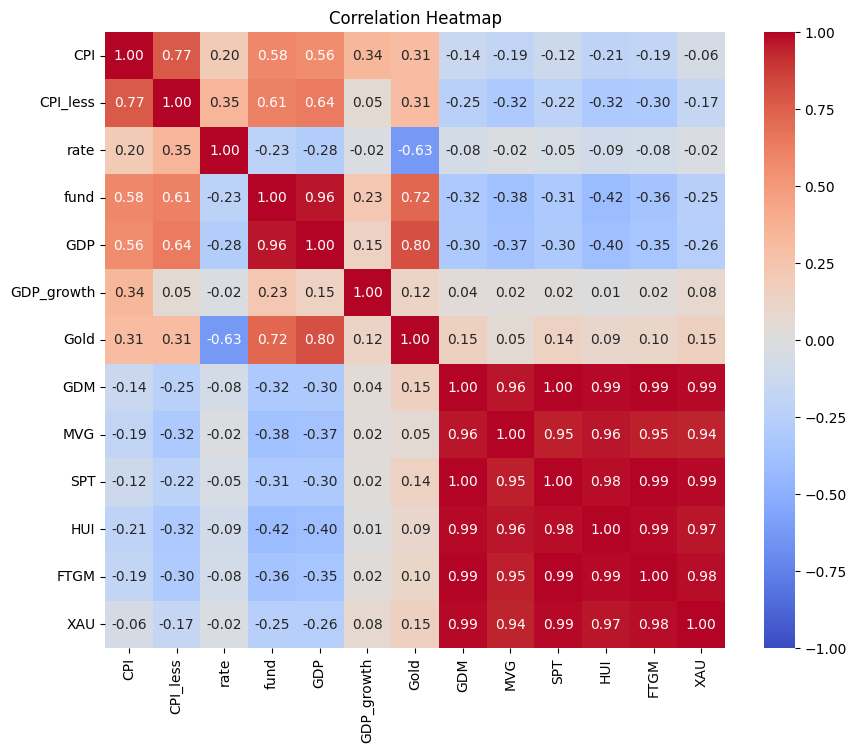

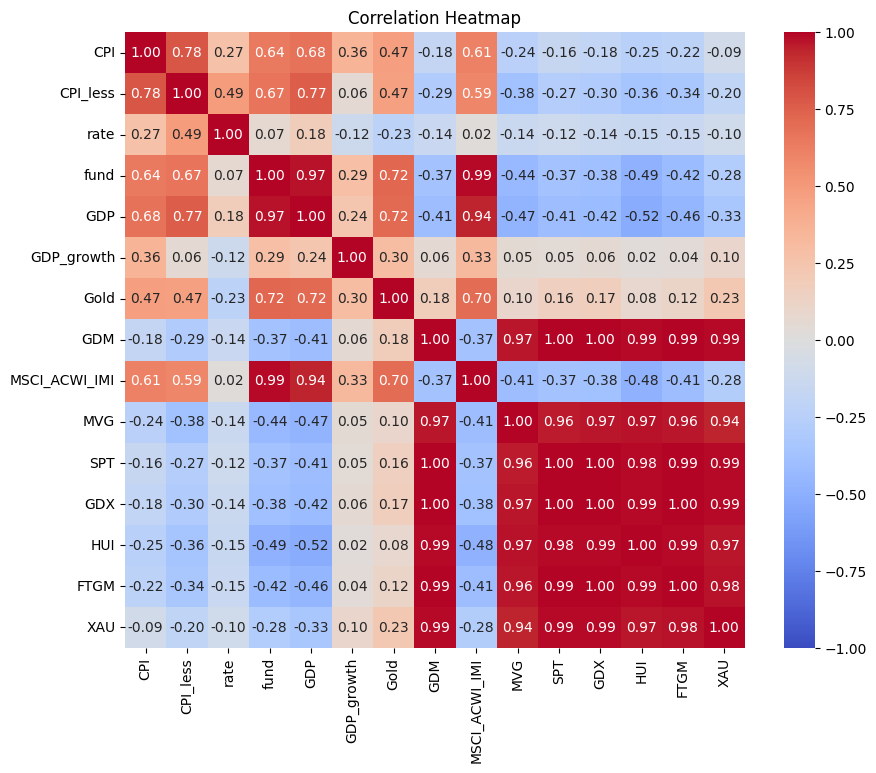

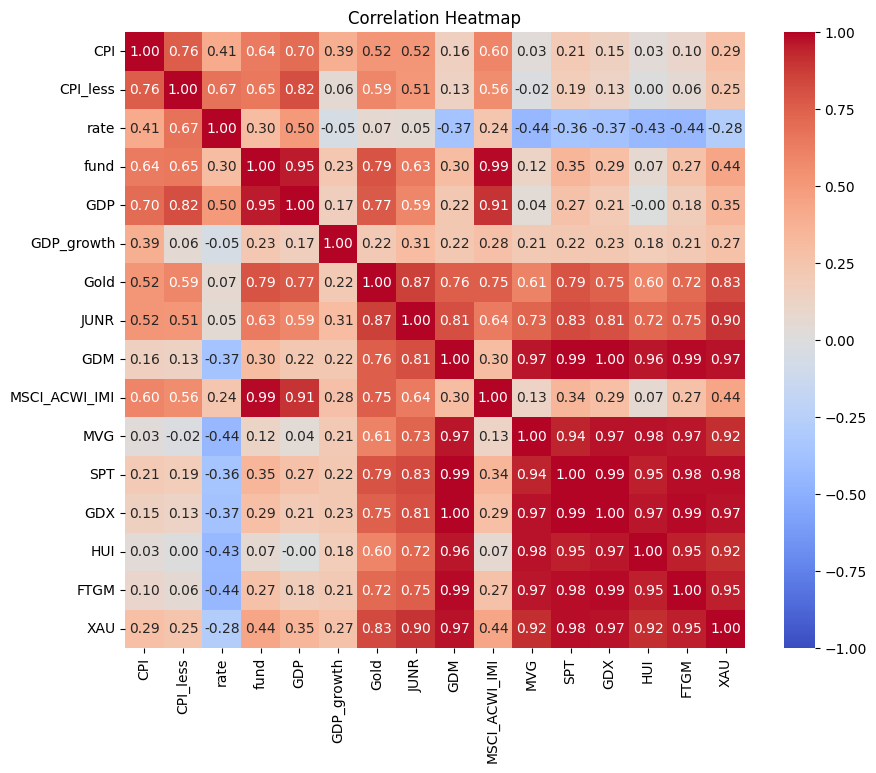

In [304]:
def Corr(df):
    correlation_matrix = df.corr()
    # correlation_matrix.columns = 
    # correlation_matrix.round(4).to_csv('data/correlation_table.csv', index=False)
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',vmin=-1, vmax=1, fmt=".2f", annot_kws={"size": 10})
    plt.title('Correlation Heatmap')
    plt.interactive(False)
    plt.show()

    # print(correlation_matrix.round(4))

Corr(dataset_2004.drop('Date', axis=1))
Corr(dataset_2008.drop('Date', axis=1))
Corr(dataset_2012.drop('Date', axis=1))

## Графики

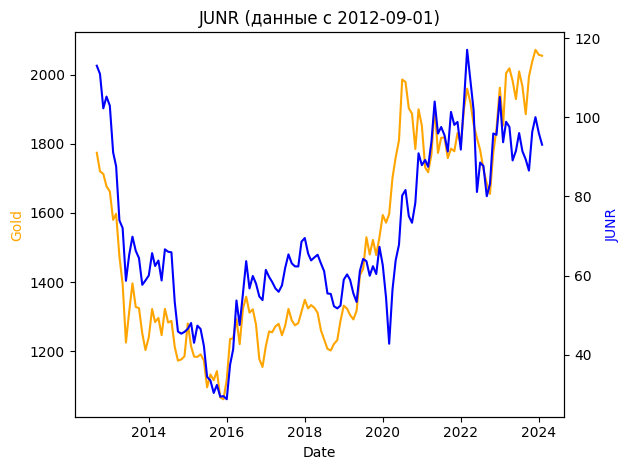

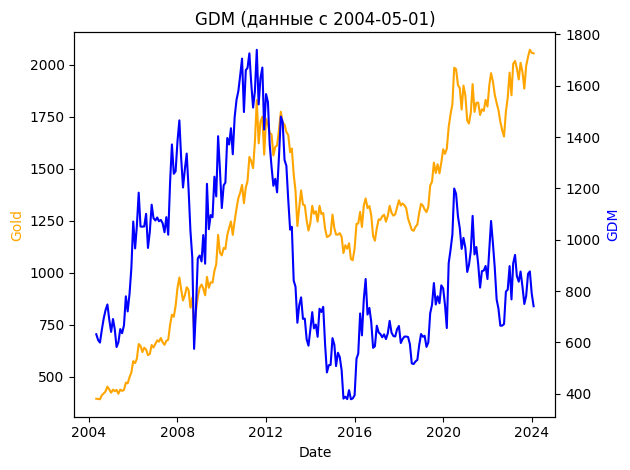

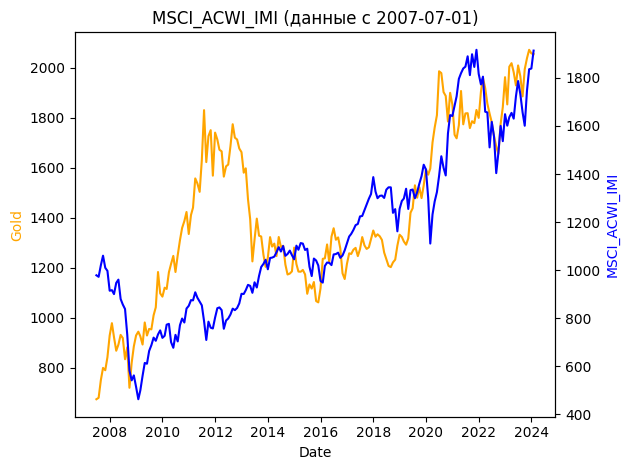

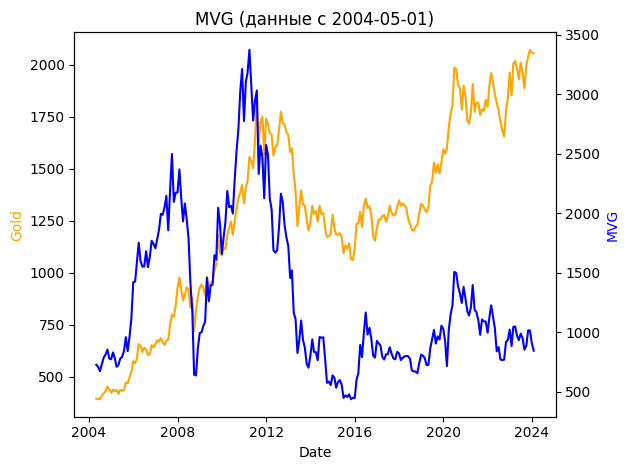

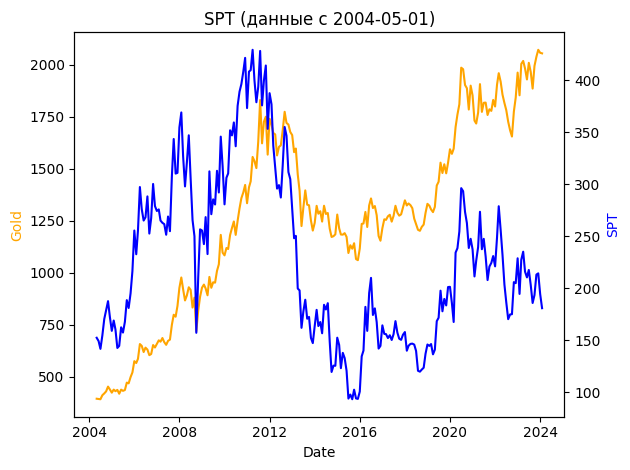

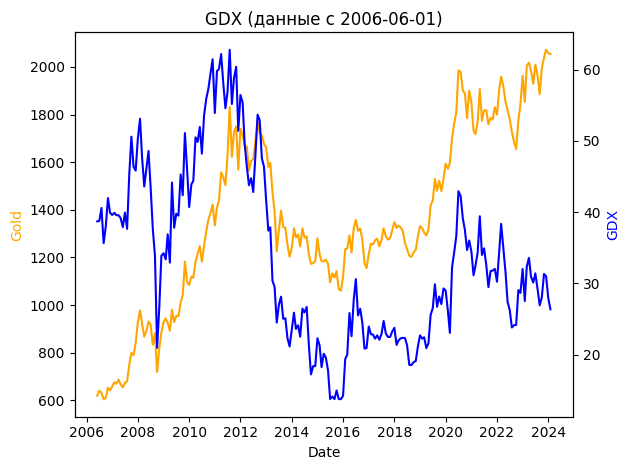

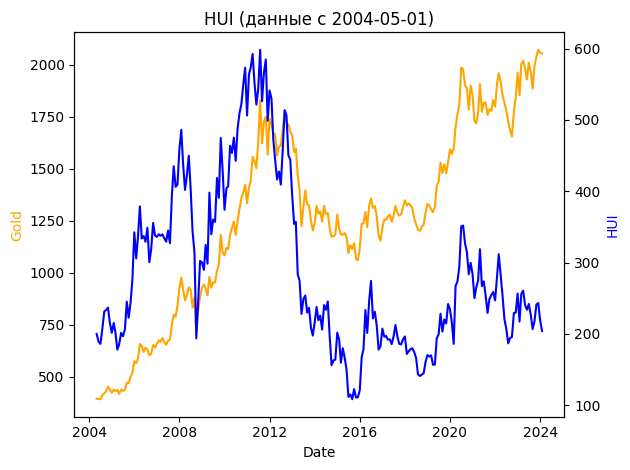

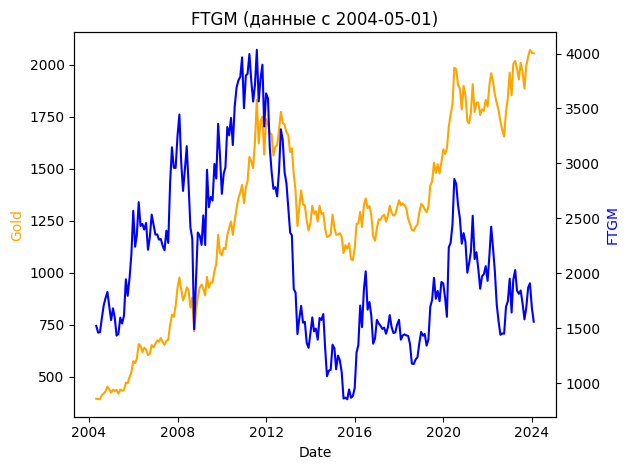

In [305]:
for target in targets:
    fig, ax1 = plt.subplots()

    filtered_data = final_df[final_df[target].notna()]
    
    ax1.plot(filtered_data['Date'], filtered_data['Gold'], color='orange')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Gold', color='orange')

    ax2 = ax1.twinx()

    ax2.plot(filtered_data['Date'], filtered_data[target], color='blue')
    ax2.set_ylabel(target, color='blue')

    plt.title(f"{target} (данные с {filtered_data['Date'].min().strftime('%Y-%m-%d')})")
    
    plt.tight_layout()
    plt.show()

В связи с тестом на стационарность и корреляционной матрицей посмотрим графики с 2012 года

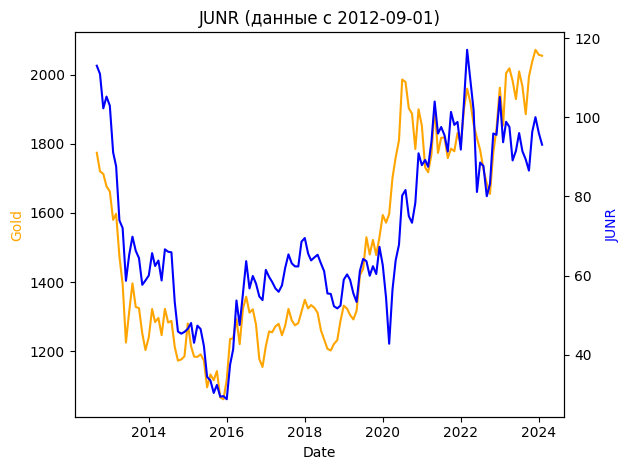

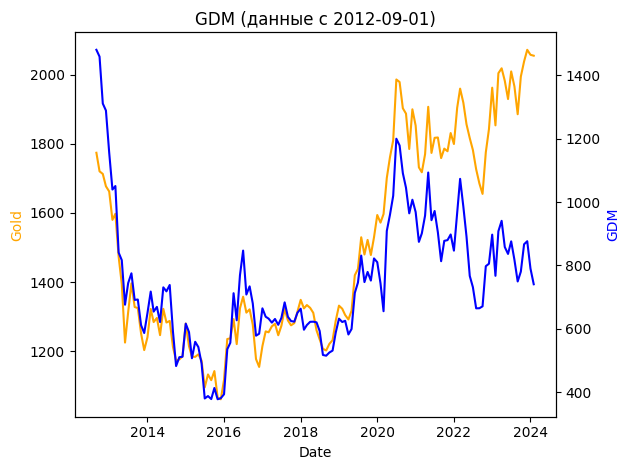

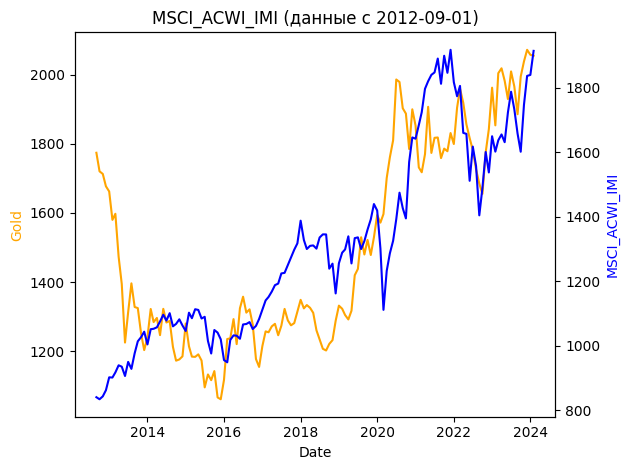

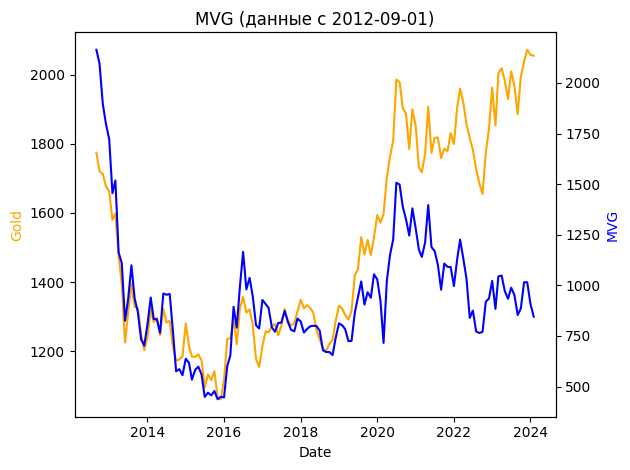

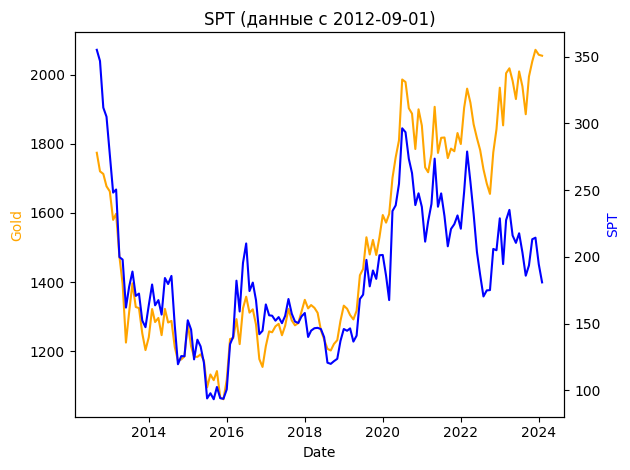

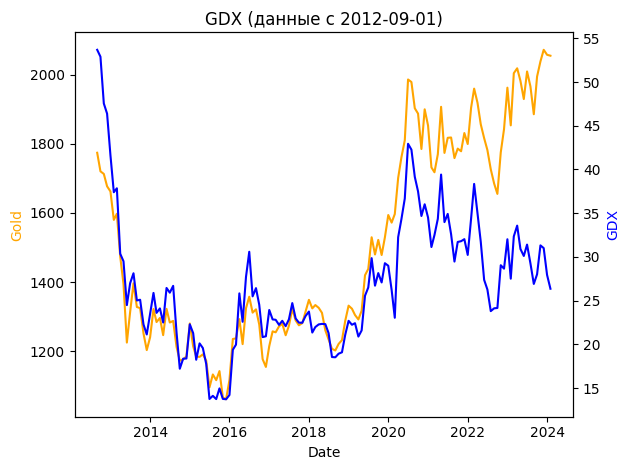

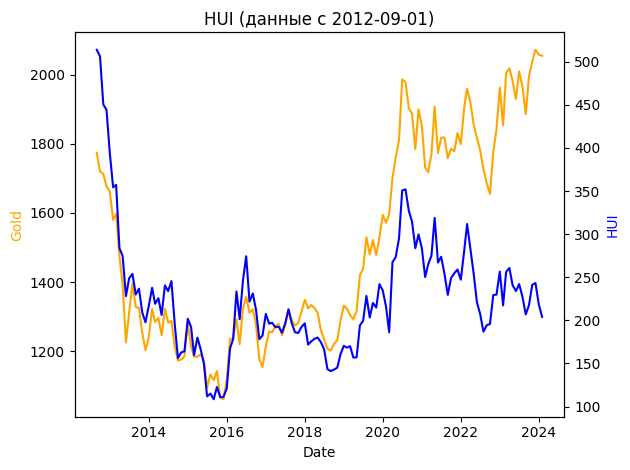

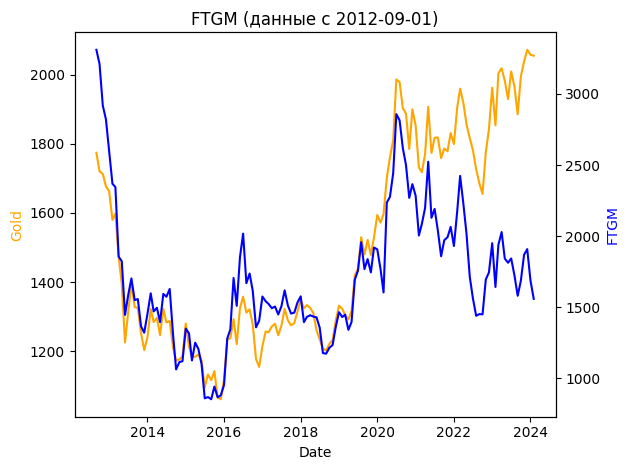

In [306]:
for target in targets:
    fig, ax1 = plt.subplots()

    filtered_data = dataset_2012.reset_index()
    
    ax1.plot(filtered_data['Date'], filtered_data['Gold'], color='orange')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Gold', color='orange')

    ax2 = ax1.twinx()

    ax2.plot(filtered_data['Date'], filtered_data[target], color='blue')
    ax2.set_ylabel(target, color='blue')

    plt.title(f"{target} (данные с {filtered_data['Date'].min().strftime('%Y-%m-%d')})")
    
    plt.tight_layout()
    plt.show()

## Тесты

In [307]:
# !pip3 install statsmodels

In [308]:
macro_vars = ['CPI', 'CPI_less', 'rate', 'fund', 'GDP', 'GDP_growth']
gold_price = ['Gold']
indices = ['JUNR', 'GDM', 'MSCI_ACWI_IMI', 'MVG', 'SPT', 'GDX', 'HUI', 'FTGM', 'XAU']

for dataset in [dataset_2004, dataset_2012, dataset_2008]:
    dataset.set_index('Date', inplace=True)

In [309]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries, alpha=0.05):
    """Проверка стационарности с помощью ADF теста"""
    result = adfuller(timeseries.dropna())
    p_value = result[1]
    is_stationary = p_value < alpha
    return p_value, is_stationary


for dataset, year in [(dataset_2004, 2004), (dataset_2012, 2012), (dataset_2008, 2008)]:
    print(f"\nADF тесты для dataset_{year}:")
    for column in dataset.columns:
        p_value, stationary = check_stationarity(dataset[column])
        print(f"{column}: p-value = {p_value:.4f}, stationary = {stationary}")


ADF тесты для dataset_2004:
CPI: p-value = 0.2860, stationary = False
CPI_less: p-value = 0.8242, stationary = False
rate: p-value = 0.1797, stationary = False
fund: p-value = 0.9980, stationary = False
GDP: p-value = 0.9987, stationary = False
GDP_growth: p-value = 0.0152, stationary = True
Gold: p-value = 0.6962, stationary = False
GDM: p-value = 0.2557, stationary = False
MVG: p-value = 0.3107, stationary = False
SPT: p-value = 0.2342, stationary = False
HUI: p-value = 0.3618, stationary = False
FTGM: p-value = 0.2795, stationary = False
XAU: p-value = 0.2369, stationary = False

ADF тесты для dataset_2012:
CPI: p-value = 0.5013, stationary = False
CPI_less: p-value = 0.9730, stationary = False
rate: p-value = 0.5254, stationary = False
fund: p-value = 0.9825, stationary = False
GDP: p-value = 0.9960, stationary = False
GDP_growth: p-value = 0.0057, stationary = True
Gold: p-value = 0.8484, stationary = False
JUNR: p-value = 0.2150, stationary = False
GDM: p-value = 0.0037, station

Все макроэкономические показатели (кроме GDP_growth) нестационарны во всех периодах

GDP_growth стационарен - это логично, так как это уже темпы изменения

В dataset_2004 ВСЕ индексы нестационарны

В dataset_2012 большинство индексов СТАЦИОНАРНЫ (GDM, MVG, SPT, GDX, HUI, FTGM, XAU)

В dataset_2008 снова ВСЕ индексы нестационарны

**Важно:** Тест показывает, что до 2012 года все индексы не стационарны, а после, они воли в тренд и стали стационарными. 

Почему в 2012 году индексы стали стационарными? Возможные причины:

* Изменение рыночной динамики

* Структурные изменения в золотодобывающей отрасли

* Макроэкономические шоки

Тесты на парную коинтеграцию для 2004 и 2008

In [310]:
from statsmodels.tsa.stattools import coint

for dataset, year in [(dataset_2004, 2004), (dataset_2008, 2008)]:
    print(f"\nКоинтеграция для dataset_{year}:")
    cur_indices = ['GDM', 'MVG', 'SPT', 'HUI', 'FTGM', 'XAU']
    if 'GDX' in dataset.columns:
        cur_indices.append('GDX')
    
    for index in cur_indices:
        data_pair = dataset[['Gold', index]].dropna()
        
        score, p_value, _ = coint(data_pair['Gold'], data_pair[index])
        print(f"Gold vs {index}: p-value={p_value:.4f}, коинтегрированы={p_value < 0.05}")


Коинтеграция для dataset_2004:
Gold vs GDM: p-value=0.9446, коинтегрированы=False
Gold vs MVG: p-value=0.9004, коинтегрированы=False
Gold vs SPT: p-value=0.9401, коинтегрированы=False
Gold vs HUI: p-value=0.9194, коинтегрированы=False
Gold vs FTGM: p-value=0.9291, коинтегрированы=False
Gold vs XAU: p-value=0.9385, коинтегрированы=False

Коинтеграция для dataset_2008:
Gold vs GDM: p-value=0.9401, коинтегрированы=False
Gold vs MVG: p-value=0.9282, коинтегрированы=False
Gold vs SPT: p-value=0.9367, коинтегрированы=False
Gold vs HUI: p-value=0.9297, коинтегрированы=False
Gold vs FTGM: p-value=0.9358, коинтегрированы=False
Gold vs XAU: p-value=0.8957, коинтегрированы=False
Gold vs GDX: p-value=0.9391, коинтегрированы=False


In [374]:
from scipy.stats import jarque_bera, normaltest, skew, kurtosis

def test_returns_normality(returns_series):
    """Полный тест на нормальность распределения"""
    jb_stat, jb_p = jarque_bera(returns_series)
    norm_stat, norm_p = normaltest(returns_series)
    
    return {
        'JB_p-value': jb_p,
        'Normal_test_p-value': norm_p,
        'Skewness': skew(returns_series),
        'Kurtosis': kurtosis(returns_series),
        'Is_normal': (jb_p > 0.05) and (norm_p > 0.05)
    }

for dataset, year in [(dataset_2004, 2004), (dataset_2012, 2012), (dataset_2008, 2008)]:
    for column in dataset.columns:
        results = test_returns_normality(returns_2008[column].dropna())
        print(f"{column}: {results}")

KeyError: 'CPI'

In [312]:
for dataset, year in [(dataset_2004, 2004), (dataset_2008, 2008)]:
    print(f"\nADF тесты для первых разностей (dataset_{year}):")
    for column in ['Gold', 'GDM', 'MVG', 'SPT', 'HUI', 'FTGM', 'XAU']:
        returns = np.log(dataset_2008[column]).diff().dropna()
        p_value, stationary = check_stationarity(returns)
        print(f"Δ{column}: p-value={p_value:.5f}, stationary={stationary}")


ADF тесты для первых разностей (dataset_2004):
ΔGold: p-value=0.00000, stationary=True
ΔGDM: p-value=0.00000, stationary=True
ΔMVG: p-value=0.00000, stationary=True
ΔSPT: p-value=0.00000, stationary=True
ΔHUI: p-value=0.00000, stationary=True
ΔFTGM: p-value=0.00000, stationary=True
ΔXAU: p-value=0.00000, stationary=True

ADF тесты для первых разностей (dataset_2008):
ΔGold: p-value=0.00000, stationary=True
ΔGDM: p-value=0.00000, stationary=True
ΔMVG: p-value=0.00000, stationary=True
ΔSPT: p-value=0.00000, stationary=True
ΔHUI: p-value=0.00000, stationary=True
ΔFTGM: p-value=0.00000, stationary=True
ΔXAU: p-value=0.00000, stationary=True


Коинтеграции нет, но первые разности стационарны, поэтому проверим модель VAR 

In [ ]:
def prepare_extended_returns(dataset, gold_col='Gold', indices_cols=None, macro_cols=None):
    """Подготовка данных с макропеременными"""
    if indices_cols is None:
        indices_cols = ['GDM', 'MVG', 'SPT', 'HUI', 'FTGM', 'XAU']
        if 'GDX' in dataset.columns:
            indices_cols.append('GDX')
    
    if macro_cols is None:
        macro_cols = ['CPI', 'CPI_less', 'rate', 'fund', 'GDP', 'GDP_growth']
    
    selected_cols = [gold_col] + indices_cols + macro_cols
    data = dataset[selected_cols].copy()
    
    financial_cols = [gold_col] + indices_cols
    macro_only_cols = macro_cols
    
    returns_data = pd.DataFrame(index=data.index)
    
    for col in financial_cols:
        if col in data.columns:
            returns_data[f'ret_{col}'] = np.log(data[col]).diff()
    
    for col in macro_only_cols:
        if col in data.columns:
            _, stationary = check_stationarity(data[col].dropna())
            if stationary:
                returns_data[f'macro_{col}'] = data[col]
            else:
                returns_data[f'macro_{col}'] = data[col].diff()
    
    return returns_data.dropna()

# Подготовка расширенных данных
extended_returns_2004 = prepare_extended_returns(dataset_2004)
extended_returns_2008 = prepare_extended_returns(dataset_2008)

print("Колонки в расширенном датасете 2004:")
print(extended_returns_2004.columns.tolist())

Колонки в расширенном датасете 2004:
['ret_Gold', 'ret_GDM', 'ret_MVG', 'ret_SPT', 'ret_HUI', 'ret_FTGM', 'ret_XAU', 'macro_CPI', 'macro_CPI_less', 'macro_rate', 'macro_fund', 'macro_GDP', 'macro_GDP_growth']


In [327]:
def check_extended_stationarity(returns_df, period_name):
    """Проверка стационарности всех переменных"""
    print(f"\nСТАЦИОНАРНОСТЬ ДЛЯ {period_name}:")
    
    financial_vars = [col for col in returns_df.columns if col.startswith('ret_')]
    macro_vars = [col for col in returns_df.columns if col.startswith('macro_')]
    
    print("\nФинансовые переменные (доходности):")
    for col in financial_vars:
        p_value, stationary = check_stationarity(returns_df[col])
        print(f"  {col}: p-value={p_value:.6f} {'✓' if stationary else '✗'}")
    
    print("\nМакропеременные:")
    for col in macro_vars:
        p_value, stationary = check_stationarity(returns_df[col])
        print(f"  {col}: p-value={p_value:.6f} {'✓' if stationary else '✗'}")

check_extended_stationarity(extended_returns_2004, "2004-2012")
check_extended_stationarity(extended_returns_2008, "2008-2012")


СТАЦИОНАРНОСТЬ ДЛЯ 2004-2012:

Финансовые переменные (доходности):
  ret_Gold: p-value=0.000000 ✓
  ret_GDM: p-value=0.000000 ✓
  ret_MVG: p-value=0.000000 ✓
  ret_SPT: p-value=0.000000 ✓
  ret_HUI: p-value=0.000000 ✓
  ret_FTGM: p-value=0.000000 ✓
  ret_XAU: p-value=0.000000 ✓

Макропеременные:
  macro_CPI: p-value=0.000000 ✓
  macro_CPI_less: p-value=0.000063 ✓
  macro_rate: p-value=0.000000 ✓
  macro_fund: p-value=0.000113 ✓
  macro_GDP: p-value=0.080092 ✗
  macro_GDP_growth: p-value=0.015116 ✓

СТАЦИОНАРНОСТЬ ДЛЯ 2008-2012:

Финансовые переменные (доходности):
  ret_Gold: p-value=0.000000 ✓
  ret_GDM: p-value=0.000000 ✓
  ret_MVG: p-value=0.000000 ✓
  ret_SPT: p-value=0.000000 ✓
  ret_HUI: p-value=0.000000 ✓
  ret_FTGM: p-value=0.000000 ✓
  ret_XAU: p-value=0.000000 ✓
  ret_GDX: p-value=0.000000 ✓

Макропеременные:
  macro_CPI: p-value=0.000000 ✓
  macro_CPI_less: p-value=0.000117 ✓
  macro_rate: p-value=0.000000 ✓
  macro_fund: p-value=0.000039 ✓
  macro_GDP: p-value=0.070837 ✗
 

In [328]:
def select_optimal_lags(returns_df, max_lags=10):
    """Выбор оптимального количества лагов для VAR модели"""
    model = VAR(returns_df)
    
    selection_results = model.select_order(maxlags=max_lags)
    
    lag_results = {
        'aic': selection_results.aic,
        'bic': selection_results.bic, 
        'hqic': selection_results.hqic
    }
    
    print(f"Рекомендуемые лаги:")
    for ic, lag in lag_results.items():
        print(f"  {ic.upper()}: {lag} лагов")
    
    optimal_lags = lag_results['aic']
    return optimal_lags

extended_returns_2004.index.freq = 'MS'  # Явно устанавливаем месячную частоту
extended_returns_2008.index.freq = 'MS'

print("Для 2004 года:")
lags_2004 = select_optimal_lags(extended_returns_2004)

print("\nДля 2008 года:")
lags_2008 = select_optimal_lags(extended_returns_2008)

Для 2004 года:
Рекомендуемые лаги:
  AIC: 1 лагов
  BIC: 1 лагов
  HQIC: 1 лагов

Для 2008 года:
Рекомендуемые лаги:
  AIC: 10 лагов
  BIC: 1 лагов
  HQIC: 1 лагов


Значит для обоих датафреймов будем использовать 1 лаг

In [ ]:
def build_extended_var(returns_df, lags, period_name):
    """Построение расширенной VAR модели с макропеременными"""
    print(f"\n{'='*60}")
    print(f"РАСШИРЕННАЯ VAR МОДЕЛЬ С МАКРОПЕРЕМЕННЫМИ - {period_name}")
    print(f"{'='*60}")
    
    model = VAR(returns_df)
    result = model.fit(lags, ic='aic')
    
    print(f"\n1. ИНФОРМАЦИЯ О МОДЕЛИ:")
    print(f"Переменные: {list(returns_df.columns)}")
    print(f"Наблюдения: {result.nobs}, Лаги: {result.k_ar}")
    
    print(f"\n2. КАЧЕСТВО МОДЕЛИ:")
    
    # Способ 1: Попробуем получить R² через атрибут rsquared
    if hasattr(result, 'rsquared'):
        print("R² по уравнениям:")
        for i, col in enumerate(returns_df.columns):
            if i < len(result.rsquared):
                r_squared = result.rsquared[i]
                print(f"  {col}: R² = {r_squared:.4f}")
            else:
                print(f"  {col}: R² = индекс вне диапазона")
    
    # Способ 2: Рассчитаем R² вручную
    else:
        print("Расчет R² вручную:")
        y_true = returns_df.iloc[lags:]  # Фактические значения
        y_pred = result.fittedvalues      # Предсказанные значения
        
        for col in returns_df.columns:
            if col in y_true.columns and col in y_pred.columns:
                ss_res = ((y_true[col] - y_pred[col]) ** 2).sum()
                ss_tot = ((y_true[col] - y_true[col].mean()) ** 2).sum()
                
                if ss_tot != 0:
                    r_squared = 1 - (ss_res / ss_tot)
                else:
                    r_squared = float('nan')
                
                print(f"  {col}: R² = {r_squared:.4f}")
    
    print(f"\n3. ИНФОРМАЦИОННЫЕ КРИТЕРИИ:")
    print(f"  AIC: {result.aic:.4f}")
    print(f"  BIC: {result.bic:.4f}")
    print(f"  FPE: {result.fpe:.4f}")
    print(f"  HQIC: {result.hqic:.4f}")
    
    print(f"\n4. ДИАГНОСТИКА МОДЕЛИ:")
    print(f"  Число параметров на уравнение: {result.params.shape[1]}")
    print(f"  Степени свободы: {result.df_resid}")
    
    return result

# Построение расширенных моделей
extended_var_2004 = build_extended_var(extended_returns_2004, 1, "2004-2024")
extended_var_2008 = build_extended_var(extended_returns_2008, 1, "2008-2024")


РАСШИРЕННАЯ VAR МОДЕЛЬ С МАКРОПЕРЕМЕННЫМИ - 2004-2024

1. ИНФОРМАЦИЯ О МОДЕЛИ:
Переменные: ['ret_Gold', 'ret_GDM', 'ret_MVG', 'ret_SPT', 'ret_HUI', 'ret_FTGM', 'ret_XAU', 'macro_CPI', 'macro_CPI_less', 'macro_rate', 'macro_fund', 'macro_GDP', 'macro_GDP_growth']
Наблюдения: 236, Лаги: 1

2. КАЧЕСТВО МОДЕЛИ:
Расчет R² вручную:
  ret_Gold: R² = 0.0491
  ret_GDM: R² = 0.0425
  ret_MVG: R² = 0.0452
  ret_SPT: R² = 0.0493
  ret_HUI: R² = 0.0464
  ret_FTGM: R² = 0.0439
  ret_XAU: R² = 0.0485
  macro_CPI: R² = 0.1321
  macro_CPI_less: R² = 0.3818
  macro_rate: R² = 0.1914
  macro_fund: R² = 0.0786
  macro_GDP: R² = 0.5352
  macro_GDP_growth: R² = 0.5060

3. ИНФОРМАЦИОННЫЕ КРИТЕРИИ:
  AIC: -63.4004
  BIC: -60.7292
  FPE: 0.0000
  HQIC: -62.3236

4. ДИАГНОСТИКА МОДЕЛИ:
  Число параметров на уравнение: 13
  Степени свободы: 222

РАСШИРЕННАЯ VAR МОДЕЛЬ С МАКРОПЕРЕМЕННЫМИ - 2008-2024

1. ИНФОРМАЦИЯ О МОДЕЛИ:
Переменные: ['ret_Gold', 'ret_GDM', 'ret_MVG', 'ret_SPT', 'ret_HUI', 'ret_FTGM', 'ret_XAU

In [345]:
def simple_gold_influence_analysis(returns_df, lags, period_name):
    """Простой анализ влияния золота"""
    print(f"\n{'='*60}")
    print(f"ПРОСТОЙ АНАЛИЗ ВЛИЯНИЯ ЗОЛОТА - {period_name}")
    print(f"{'='*60}")
    
    model = VAR(returns_df)
    result = model.fit(lags, ic='aic')
    
    # Просто выведем всю таблицу коэффициентов
    print("ПОЛНАЯ ТАБЛИЦА КОЭФФИЦИЕНТОВ:")
    print(result.params.round(4))
    
    # Отфильтруем только коэффициенты влияния золота
    print(f"\nФИЛЬТР: КОЭФФИЦИЕНТЫ ВЛИЯНИЯ GOLD:")
    gold_coeffs = result.params[result.params.index.str.contains('ret_Gold')]
    
    if not gold_coeffs.empty:
        print(gold_coeffs.round(4))
        
        # Интерпретация
        print(f"\nИНТЕРПРЕТАЦИЯ:")
        mining_vars = [col for col in returns_df.columns if col.startswith('ret_') and col != 'ret_Gold']
        for mining_var in mining_vars:
            if mining_var in gold_coeffs.columns:
                coeff = gold_coeffs[mining_var].iloc[0]  # Берем первый лаг
                print(f"  {mining_var}: {coeff:.4f} - ", end="")
                if coeff > 0.1:
                    print("СИЛЬНОЕ положительное влияние")
                elif coeff > 0.01:
                    print("умеренное положительное влияние")
                elif coeff > -0.01:
                    print("слабое влияние")
                elif coeff > -0.1:
                    print("умеренное отрицательное влияние")
                else:
                    print("СИЛЬНОЕ отрицательное влияние")
    else:
        print("Коэффициенты влияния золота не найдены!")
    
    return result

# Простой анализ
print("Для 2004 года:")
simple_2004 = simple_gold_influence_analysis(extended_returns_2004, 1, "2004-2024")

print("\nДля 2008 года:")
simple_2008 = simple_gold_influence_analysis(extended_returns_2008, 1, "2008-2024")

Для 2004 года:

ПРОСТОЙ АНАЛИЗ ВЛИЯНИЯ ЗОЛОТА - 2004-2024
ПОЛНАЯ ТАБЛИЦА КОЭФФИЦИЕНТОВ:
                     ret_Gold  ret_GDM  ret_MVG  ret_SPT  ret_HUI  ret_FTGM  \
const                  0.0090   0.0079   0.0063   0.0073   0.0066    0.0071   
L1.ret_Gold           -0.2750  -0.3545  -0.6453  -0.3342  -0.3241   -0.3334   
L1.ret_GDM             0.4288   0.4181   1.0538   0.5725   0.5714    0.4896   
L1.ret_MVG            -0.0307  -0.0115  -0.0049  -0.0316  -0.0111   -0.0229   
L1.ret_SPT            -0.3093  -0.5895  -0.4203  -0.7767  -0.7402   -0.5131   
L1.ret_HUI             0.0094   0.1412   0.0575   0.1024  -0.0286   -0.0246   
L1.ret_FTGM            0.1670   0.3978  -0.0170   0.4335   0.5186    0.3389   
L1.ret_XAU            -0.1829  -0.2829  -0.3625  -0.2556  -0.2513   -0.1891   
L1.macro_CPI           0.0186   0.0033   0.0611  -0.0151   0.0088   -0.0133   
L1.macro_CPI_less      0.0105   0.0280  -0.0102   0.0454   0.0361    0.0319   
L1.macro_rate          0.0010   0.0296   0.

### 2012-2024

In [346]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt

def check_stationarity(timeseries, alpha=0.05):
    result = adfuller(timeseries.dropna())
    p_value = result[1]
    is_stationary = p_value < alpha
    return p_value, is_stationary

def prepare_2012_data(dataset_2012):
    financial_vars = ['Gold', 'JUNR', 'GDM', 'MSCI_ACWI_IMI', 'MVG', 'SPT', 'GDX', 'HUI', 'FTGM', 'XAU']
    macro_vars = ['CPI', 'CPI_less', 'rate', 'fund', 'GDP', 'GDP_growth']
    
    prepared_data = pd.DataFrame(index=dataset_2012.index)
    
    print("СТАТУС СТАЦИОНАРНОСТИ ФИНАНСОВЫХ ПЕРЕМЕННЫХ:")
    for var in financial_vars:
        p_value, stationary = check_stationarity(dataset_2012[var])
        status = "СТАЦИОНАРНА" if stationary else "НЕСТАЦИОНАРНА"
        print(f"  {var}: p-value={p_value:.4f} ({status})")
        
        if stationary:
            prepared_data[f'level_{var}'] = dataset_2012[var]
        else:
            prepared_data[f'ret_{var}'] = np.log(dataset_2012[var]).diff()
    
    print("\nСТАТУС СТАЦИОНАРНОСТИ МАКРОПЕРЕМЕННЫХ:")
    for var in macro_vars:
        p_value, stationary = check_stationarity(dataset_2012[var])
        status = "СТАЦИОНАРНА" if stationary else "НЕСТАЦИОНАРНА"
        print(f"  {var}: p-value={p_value:.4f} ({status})")
        
        if stationary:
            prepared_data[f'macro_{var}'] = dataset_2012[var]
        else:
            prepared_data[f'macro_{var}'] = dataset_2012[var].diff()
    
    return prepared_data.dropna()

data_2012 = prepare_2012_data(dataset_2012)
print(f"\nРазмерность подготовленных данных: {data_2012.shape}")
print(f"Колонки: {data_2012.columns.tolist()}")

СТАТУС СТАЦИОНАРНОСТИ ФИНАНСОВЫХ ПЕРЕМЕННЫХ:
  Gold: p-value=0.8484 (НЕСТАЦИОНАРНА)
  JUNR: p-value=0.2150 (НЕСТАЦИОНАРНА)
  GDM: p-value=0.0037 (СТАЦИОНАРНА)
  MSCI_ACWI_IMI: p-value=0.8285 (НЕСТАЦИОНАРНА)
  MVG: p-value=0.0004 (СТАЦИОНАРНА)
  SPT: p-value=0.0076 (СТАЦИОНАРНА)
  GDX: p-value=0.0029 (СТАЦИОНАРНА)
  HUI: p-value=0.0003 (СТАЦИОНАРНА)
  FTGM: p-value=0.0053 (СТАЦИОНАРНА)
  XAU: p-value=0.0212 (СТАЦИОНАРНА)

СТАТУС СТАЦИОНАРНОСТИ МАКРОПЕРЕМЕННЫХ:
  CPI: p-value=0.5013 (НЕСТАЦИОНАРНА)
  CPI_less: p-value=0.9730 (НЕСТАЦИОНАРНА)
  rate: p-value=0.5254 (НЕСТАЦИОНАРНА)
  fund: p-value=0.9825 (НЕСТАЦИОНАРНА)
  GDP: p-value=0.9960 (НЕСТАЦИОНАРНА)
  GDP_growth: p-value=0.0057 (СТАЦИОНАРНА)

Размерность подготовленных данных: (137, 16)
Колонки: ['ret_Gold', 'ret_JUNR', 'level_GDM', 'ret_MSCI_ACWI_IMI', 'level_MVG', 'level_SPT', 'level_GDX', 'level_HUI', 'level_FTGM', 'level_XAU', 'macro_CPI', 'macro_CPI_less', 'macro_rate', 'macro_fund', 'macro_GDP', 'macro_GDP_growth']


In [347]:
def create_optimal_var_dataset(data_2012):
    """Создание оптимального набора переменных для VAR модели"""
    
    
    financial_vars = ['ret_Gold']
    index_candidates = ['ret_GDM', 'level_MVG', 'level_SPT', 'level_GDX', 'level_HUI']
    available_indices = [idx for idx in index_candidates if idx in data_2012.columns]
    
    selected_indices = available_indices[:3]
    financial_vars.extend(selected_indices)
    
    macro_candidates = ['macro_rate', 'macro_CPI', 'macro_GDP_growth', 'macro_fund']
    available_macros = [mac for mac in macro_candidates if mac in data_2012.columns]
    
    selected_macros = available_macros[:2]
    
    final_vars = financial_vars + selected_macros
    
    print("ВЫБРАННЫЕ ПЕРЕМЕННЫЕ ДЛЯ VAR МОДЕЛИ:")
    for var in final_vars:
        print(f"  {var}")
    
    return data_2012[final_vars].dropna()

optimal_data_2012 = create_optimal_var_dataset(data_2012)
print(f"\nИтоговая размерность: {optimal_data_2012.shape}")

ВЫБРАННЫЕ ПЕРЕМЕННЫЕ ДЛЯ VAR МОДЕЛИ:
  ret_Gold
  level_MVG
  level_SPT
  level_GDX
  macro_rate
  macro_CPI

Итоговая размерность: (137, 6)


In [348]:
def select_var_lags(returns_df, max_lags=12):
    """Выбор оптимального количества лагов для VAR"""
    model = VAR(returns_df)
    
    print("ВЫБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА ЛАГОВ:")
    print("-" * 40)
    
    lag_results = model.select_order(maxlags=max_lags)
    
    criteria = ['aic', 'bic', 'hqic']
    for crit in criteria:
        optimal_lag = getattr(lag_results, crit)
        print(f"{crit.upper()}: {optimal_lag} лагов")
    
    optimal_lags = lag_results.aic
    print(f"\nВЫБРАНО: {optimal_lags} лагов (по AIC)")
    
    return optimal_lags

lags_2012 = select_var_lags(optimal_data_2012)

ВЫБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА ЛАГОВ:
----------------------------------------
AIC: 12 лагов
BIC: 1 лагов
HQIC: 1 лагов

ВЫБРАНО: 12 лагов (по AIC)


/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [362]:
def build_and_diagnose_var_2012(data_2012, lags):
    """Построение и полная диагностика VAR модели для 2012"""
    
    print("\n" + "="*70)
    print("ПОСТРОЕНИЕ И ДИАГНОСТИКА VAR МОДЕЛИ (2012-2024)")
    print("="*70)
    
    # Построение модели
    model = VAR(data_2012)
    result = model.fit(lags)
    
    # 1. Основная информация (исправленные атрибуты)
    print("\n1. ОСНОВНАЯ ИНФОРМАЦИЯ О МОДЕЛИ:")
    print(f"Период: {data_2012.index.min()} - {data_2012.index.max()}")
    print(f"Наблюдения: {result.nobs}")
    print(f"Количество лагов: {result.k_ar}")
    print(f"Количество переменных: {result.neqs}")  # исправленный атрибут
    
    # 2. Качество модели (R²) - вычисляем вручную
    print("\n2. КАЧЕСТВО МОДЕЛИ (R²):")
    print("-" * 40)
    
    # Вычисляем R² для каждого уравнения
    for i, column in enumerate(data_2012.columns):
        # Предсказанные значения
        fitted_values = result.fittedvalues[column] if column in result.fittedvalues else result.resid[column]
        
        # Фактические значения (с учетом лагов)
        actual_values = data_2012[column].iloc[lags:]
        
        # R²
        ss_res = np.sum(result.resid[column]**2)
        ss_tot = np.sum((actual_values - actual_values.mean())**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        interpretation = "отличное" if r_squared > 0.3 else "хорошее" if r_squared > 0.15 else "слабое"
        print(f"{column:<15}: R² = {r_squared:.4f} ({interpretation})")

    print(f"\nФИЛЬТР: КОЭФФИЦИЕНТЫ ВЛИЯНИЯ GOLD:")
    gold_coeffs = result.params[result.params.index.str.contains('ret_Gold')]
    print(gold_coeffs)

    mining_vars = [col for col in data_2012.columns if col != 'ret_Gold']
    for mining_var in mining_vars:
        if mining_var in gold_coeffs.columns:
            coeff = gold_coeffs[mining_var].iloc[0]  # Берем первый лаг
            print(f"  {mining_var}: {coeff:.4f} - ", end="")
            if coeff > 0.1:
                print("СИЛЬНОЕ положительное влияние")
            elif coeff > 0.01:
                print("умеренное положительное влияние")
            elif coeff > -0.01:
                print("слабое влияние")
            elif coeff > -0.1:
                print("умеренное отрицательное влияние")
            else:
                print("СИЛЬНОЕ отрицательное влияние")
    
    # 3. Информационные критерии
    print("\n3. ИНФОРМАЦИОННЫЕ КРИТЕРИИ:")
    print(f"AIC: {result.aic:.2f}")
    print(f"BIC: {result.bic:.2f}")
    print(f"HQIC: {result.hqic:.2f}")
    
    return result

var_result_2012 = build_and_diagnose_var_2012(optimal_data_2012, 1)



ПОСТРОЕНИЕ И ДИАГНОСТИКА VAR МОДЕЛИ (2012-2024)

1. ОСНОВНАЯ ИНФОРМАЦИЯ О МОДЕЛИ:
Период: 2012-10-01 00:00:00 - 2024-02-01 00:00:00
Наблюдения: 136
Количество лагов: 1
Количество переменных: 6

2. КАЧЕСТВО МОДЕЛИ (R²):
----------------------------------------
ret_Gold       : R² = 0.0767 (слабое)
level_MVG      : R² = 0.8615 (отличное)
level_SPT      : R² = 0.8666 (отличное)
level_GDX      : R² = 0.8622 (отличное)
macro_rate     : R² = 0.1977 (хорошее)
macro_CPI      : R² = 0.0492 (слабое)

ФИЛЬТР: КОЭФФИЦИЕНТЫ ВЛИЯНИЯ GOLD:
             ret_Gold  level_MVG  level_SPT  level_GDX  macro_rate  macro_CPI
L1.ret_Gold -0.027629  -0.460146 -17.376729  -1.869949    -1.73883   -0.12093
  level_MVG: -0.4601 - СИЛЬНОЕ отрицательное влияние
  level_SPT: -17.3767 - СИЛЬНОЕ отрицательное влияние
  level_GDX: -1.8699 - СИЛЬНОЕ отрицательное влияние
  macro_rate: -1.7388 - СИЛЬНОЕ отрицательное влияние
  macro_CPI: -0.1209 - СИЛЬНОЕ отрицательное влияние

3. ИНФОРМАЦИОННЫЕ КРИТЕРИИ:
AIC: -5.08
BIC: 

/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [363]:
#Анализ остатков

def comprehensive_residual_diagnostics(var_result, data_2012):
    """Комплексная диагностика остатков VAR модели"""
    
    print("\n4. ДИАГНОСТИКА ОСТАТКОВ:")
    print("-" * 40)
    
    residuals = var_result.resid
    
    # Тест на автокорреляцию
    print("\nа) ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Льюнг-Бокс):")
    print("   H₀: Нет автокорреляции (p-value > 0.05)")
    print("   " + "-" * 30)
    
    for i, column in enumerate(data_2012.columns):
        lb_test = acorr_ljungbox(residuals[column], lags=[10], return_df=True)
        p_value = lb_test['lb_pvalue'].iloc[0]
        status = "✓ НЕТ автокорреляции" if p_value > 0.05 else "✗ ЕСТЬ автокорреляция"
        print(f"   {column:<15}: p-value = {p_value:.4f} [{status}]")
    
    # Тест на нормальность
    print("\nб) ТЕСТ НА НОРМАЛЬНОСТЬ (Харке-Бера):")
    print("   H₀: Распределение нормальное (p-value > 0.05)")
    print("   " + "-" * 30)
    
    for column in data_2012.columns:
        jb_stat, jb_pvalue = jarque_bera(residuals[column].dropna())
        status = "✓ НОРМАЛЬНЫ" if jb_pvalue > 0.05 else "✗ НЕНОРМАЛЬНЫ"
        print(f"   {column:<15}: p-value = {jb_pvalue:.4f} [{status}]")
    
    # Тест на гетероскедастичность
    print("\nв) ТЕСТ НА ARCH-ЭФФЕКТЫ (гетероскедастичность):")
    print("   H₀: Нет ARCH-эффектов (p-value > 0.05)")
    print("   " + "-" * 30)
    
    for column in data_2012.columns:
        try:
            arch_test = het_arch(residuals[column].dropna())
            p_value = arch_test[1]
            status = "✓ ГОМОСКЕДАСТИЧНЫ" if p_value > 0.05 else "✗ ГЕТЕРОСКЕДАСТИЧНЫ"
            print(f"   {column:<15}: p-value = {p_value:.4f} [{status}]")
        except:
            print(f"   {column:<15}: невозможно вычислить")

comprehensive_residual_diagnostics(var_result_2012, optimal_data_2012)


4. ДИАГНОСТИКА ОСТАТКОВ:
----------------------------------------

а) ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Льюнг-Бокс):
   H₀: Нет автокорреляции (p-value > 0.05)
   ------------------------------
   ret_Gold       : p-value = 0.9077 [✓ НЕТ автокорреляции]
   level_MVG      : p-value = 0.6516 [✓ НЕТ автокорреляции]
   level_SPT      : p-value = 0.8108 [✓ НЕТ автокорреляции]
   level_GDX      : p-value = 0.8575 [✓ НЕТ автокорреляции]
   macro_rate     : p-value = 0.2293 [✓ НЕТ автокорреляции]
   macro_CPI      : p-value = 0.0071 [✗ ЕСТЬ автокорреляция]

б) ТЕСТ НА НОРМАЛЬНОСТЬ (Харке-Бера):
   H₀: Распределение нормальное (p-value > 0.05)
   ------------------------------
   ret_Gold       : p-value = 0.8741 [✓ НОРМАЛЬНЫ]
   level_MVG      : p-value = 0.1243 [✓ НОРМАЛЬНЫ]
   level_SPT      : p-value = 0.0150 [✗ НЕНОРМАЛЬНЫ]
   level_GDX      : p-value = 0.0378 [✗ НЕНОРМАЛЬНЫ]
   macro_rate     : p-value = 0.0389 [✗ НЕНОРМАЛЬНЫ]
   macro_CPI      : p-value = 0.0002 [✗ НЕНОРМАЛЬНЫ]

в) ТЕСТ НА ARCH-Э

In [364]:
def granger_analysis_2012(data_2012):
    """Анализ причинности по Грэнджеру для 2012 года"""
    
    print("\n5. АНАЛИЗ ПРИЧИННОСТИ ПО ГРЭНДЖЕРУ:")
    print("=" * 50)
    print("H₀: Переменная X НЕ вызывает переменную Y (p-value > 0.05)")
    print("-" * 50)
    
    gold_col = 'ret_Gold'
    other_vars = [col for col in data_2012.columns if col != gold_col]
    
    print(f"\nа) ВЛИЯЕТ ЛИ ЗОЛОТО НА ДРУГИЕ ПЕРЕМЕННЫХ:")
    for var in other_vars:
        test_data = data_2012[[var, gold_col]].dropna()
        
        try:
            gc_result = grangercausalitytests(test_data, maxlag=5, verbose=False)
            p_values = [gc_result[lag][0]['ssr_ftest'][1] for lag in range(1, 6)]
            min_p_value = min(p_values)
            
            causality = "✓ ДА" if min_p_value < 0.05 else "✗ НЕТ"
            print(f"   Gold → {var:<15}: p-value = {min_p_value:.4f} [{causality}]")
            
        except Exception as e:
            print(f"   Gold → {var:<15}: ошибка - {e}")
    
    print(f"\nб) ВЛИЯЮТ ЛИ ДРУГИЕ ПЕРЕМЕННЫЕ НА ЗОЛОТО:")
    for var in other_vars:
        test_data = data_2012[[gold_col, var]].dropna()
        
        try:
            gc_result = grangercausalitytests(test_data, maxlag=5, verbose=False)
            p_values = [gc_result[lag][0]['ssr_ftest'][1] for lag in range(1, 6)]
            min_p_value = min(p_values)
            
            causality = "✓ ДА" if min_p_value < 0.05 else "✗ НЕТ"
            print(f"   {var:<15} → Gold: p-value = {min_p_value:.4f} [{causality}]")
            
        except Exception as e:
            print(f"   {var:<15} → Gold: ошибка - {e}")

granger_analysis_2012(optimal_data_2012)


5. АНАЛИЗ ПРИЧИННОСТИ ПО ГРЭНДЖЕРУ:
H₀: Переменная X НЕ вызывает переменную Y (p-value > 0.05)
--------------------------------------------------

а) ВЛИЯЕТ ЛИ ЗОЛОТО НА ДРУГИЕ ПЕРЕМЕННЫХ:
   Gold → level_MVG      : p-value = 0.0173 [✓ ДА]
   Gold → level_SPT      : p-value = 0.5800 [✗ НЕТ]
   Gold → level_GDX      : p-value = 0.4243 [✗ НЕТ]
   Gold → macro_rate     : p-value = 0.0001 [✓ ДА]
   Gold → macro_CPI      : p-value = 0.6692 [✗ НЕТ]

б) ВЛИЯЮТ ЛИ ДРУГИЕ ПЕРЕМЕННЫЕ НА ЗОЛОТО:
   level_MVG       → Gold: p-value = 0.0081 [✓ ДА]
   level_SPT       → Gold: p-value = 0.0292 [✓ ДА]
   level_GDX       → Gold: p-value = 0.0317 [✓ ДА]
   macro_rate      → Gold: p-value = 0.3213 [✗ НЕТ]
   macro_CPI       → Gold: p-value = 0.2131 [✗ НЕТ]


/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/lisa/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated si


6. АНАЛИЗ ИМПУЛЬСНЫХ RESPONSE ФУНКЦИЙ:

ВЛИЯНИЕ ШОКОВ В ЗОЛОТЕ НА ДРУГИЕ ПЕРЕМЕННЫЕ:
--------------------------------------------------

level_MVG:
  Максимальный эффект: 130.8693 (отрицательный, лаг 2)
  Долгосрочный эффект: -70.5061 (отрицательный)

level_SPT:
  Максимальный эффект: 32.3194 (отрицательный, лаг 2)
  Долгосрочный эффект: -16.0591 (отрицательный)

level_GDX:
  Максимальный эффект: 4.3321 (отрицательный, лаг 2)
  Долгосрочный эффект: -2.1040 (отрицательный)

macro_rate:
  Максимальный эффект: 1.7388 (отрицательный, лаг 1)
  Долгосрочный эффект: -0.0106 (отрицательный)

macro_CPI:
  Максимальный эффект: 0.1209 (отрицательный, лаг 1)
  Долгосрочный эффект: -0.0010 (отрицательный)


<Figure size 1500x1000 with 0 Axes>

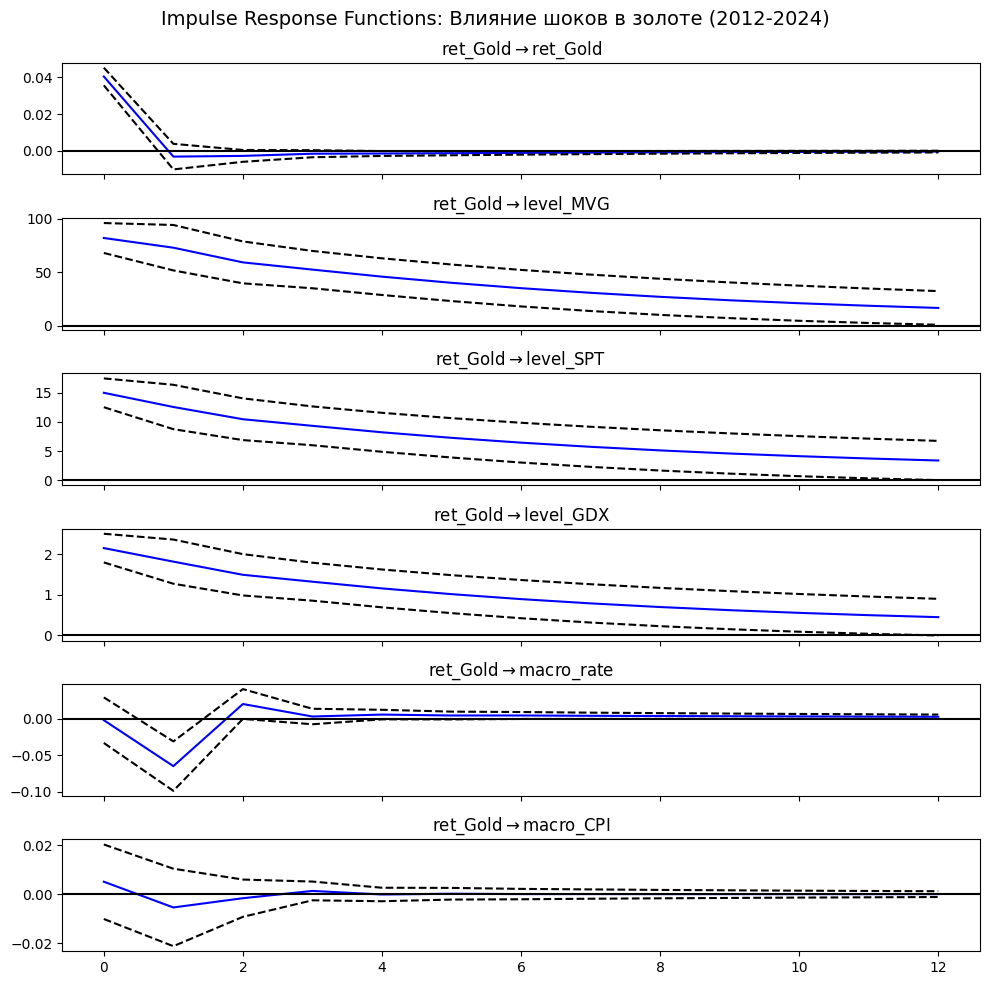

In [365]:
def impulse_response_analysis_2012(var_result, periods=12):
    """Анализ импульсных response функций для 2012 года"""
    
    print("\n6. АНАЛИЗ ИМПУЛЬСНЫХ RESPONSE ФУНКЦИЙ:")
    print("=" * 50)
    
    irf = var_result.irf(periods=periods)
    var_names = var_result.names
    
    # Анализ влияния шоков в золоте
    gold_idx = list(var_names).index('ret_Gold')
    
    print(f"\nВЛИЯНИЕ ШОКОВ В ЗОЛОТЕ НА ДРУГИЕ ПЕРЕМЕННЫЕ:")
    print("-" * 50)
    
    for i, var_name in enumerate(var_names):
        if i != gold_idx:
            response = irf.irfs[:, i, gold_idx]
            
            # Максимальный отклик
            max_effect = np.max(np.abs(response))
            max_effect_period = np.argmax(np.abs(response))
            max_effect_direction = "положительный" if response[max_effect_period] > 0 else "отрицательный"
            
            # Долгосрочный эффект (последний период)
            long_term_effect = response[-1]
            lt_direction = "положительный" if long_term_effect > 0 else "отрицательный" if long_term_effect < 0 else "нулевой"
            
            print(f"\n{var_name}:")
            print(f"  Максимальный эффект: {max_effect:.4f} ({max_effect_direction}, лаг {max_effect_period})")
            print(f"  Долгосрочный эффект: {long_term_effect:.4f} ({lt_direction})")
    
    # Визуализация
    plt.figure(figsize=(15, 10))
    irf.plot(impulse='ret_Gold', orth=True)
    plt.suptitle('Impulse Response Functions: Влияние шоков в золоте (2012-2024)', fontsize=14)
    plt.tight_layout()
    plt.show()

impulse_response_analysis_2012(var_result_2012)


In [366]:
def variance_decomposition_2012(var_result, periods=10):
    """Анализ декомпозиции дисперсии для 2012 года"""
    
    print("\n7. ДЕКОМПОЗИЦИЯ ДИСПЕРСИИ ОШИБОК ПРОГНОЗА:")
    print("=" * 60)
    
    fevd = var_result.fevd(periods=periods)
    var_names = var_result.names
    
    gold_idx = list(var_names).index('ret_Gold')
    
    print(f"\nВКЛАД ШОКОВ В ЗОЛОТЕ В ДИСПЕРСИЮ ДРУГИХ ПЕРЕМЕННЫХ:")
    print(f"(горизонт прогноза: {periods} периодов)")
    print("-" * 60)
    
    for i, var_name in enumerate(var_names):
        if i != gold_idx:
            gold_contribution = fevd.decomp[i, gold_idx] * 100
            own_contribution = fevd.decomp[i, i] * 100
            
            interpretation = ""
            if gold_contribution > 20:
                interpretation = "✓ ВЫСОКИЙ вклад"
            elif gold_contribution > 10:
                interpretation = "✓ СРЕДНИЙ вклад"
            elif gold_contribution > 5:
                interpretation = "✓ СЛАБЫЙ вклад"
            else:
                interpretation = "✗ НЕЗНАЧИТЕЛЬНЫЙ"
            
            print(f"{var_name:<15}: {gold_contribution:5.1f}% от золота, {own_contribution:5.1f}% собственных шоков [{interpretation}]")
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    fevd.plot()
    plt.suptitle('Forecast Error Variance Decomposition (2012-2024)', fontsize=14)
    plt.tight_layout()
    plt.show()

variance_decomposition_2012(var_result_2012)

# Сводка основных выводов с исправленными атрибутами
def summarize_findings_2012(var_result, data_2012, lags):
    """Сводка основных выводов для 2012 года"""
    
    print("\n8. ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ПЕРИОДА 2012-2024:")
    print("=" * 60)
    
    # Анализ силы связей через R² (вычисляем вручную)
    gold_col = 'ret_Gold'
    financial_vars = [col for col in data_2012.columns if col.startswith('ret_') or col.startswith('level_')]
    financial_vars = [var for var in financial_vars if var != gold_col]
    
    print("\nСИЛА СВЯЗИ ЗОЛОТА С ИНДЕКСАМИ:")
    
    strong_links = []
    weak_links = []
    
    for var in financial_vars:
        # Вычисляем R² для каждого уравнения
        actual_values = data_2012[var].iloc[lags:]
        ss_res = np.sum(var_result.resid[var]**2)
        ss_tot = np.sum((actual_values - actual_values.mean())**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        if r_squared > 0.2:
            strong_links.append((var, r_squared))
        elif r_squared > 0.1:
            weak_links.append((var, r_squared))
    
    if strong_links:
        print("✓ СИЛЬНЫЕ СВЯЗИ (R² > 0.2):")
        for var, r2 in strong_links:
            print(f"  {var}: R² = {r2:.4f}")
    
    if weak_links:
        print("✓ СЛАБЫЕ СВЯЗИ (R² > 0.1):")
        for var, r2 in weak_links:
            print(f"  {var}: R² = {r2:.4f}")
    
    if not strong_links and not weak_links:
        print("✗ СВЯЗИ ОЧЕНЬ СЛАБЫЕ (R² < 0.1)")
    
    # Рекомендации
    print("\nПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:")
    print("• Для прогнозирования: использовать построенную VAR модель")
    print("• Для хеджирования: учитывать выявленные сильные связи")
    print("• Для инвестиционных решений: мониторить ключевые макропеременные")
    print("• Для дальнейших исследований: расширить набор индексов")

summarize_findings_2012(var_result_2012, optimal_data_2012, lags_2012)

print("\n" + "="*70)
print("АНАЛИЗ ЗАВЕРШЕН УСПЕШНО!")
print("="*70)


7. ДЕКОМПОЗИЦИЯ ДИСПЕРСИИ ОШИБОК ПРОГНОЗА:

ВКЛАД ШОКОВ В ЗОЛОТЕ В ДИСПЕРСИЮ ДРУГИХ ПЕРЕМЕННЫХ:
(горизонт прогноза: 10 периодов)
------------------------------------------------------------


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [368]:

# Альтернативная версия если предыдущая не работает
def variance_decomposition_simple_2012(var_result, periods=10):
    """Упрощенная версия декомпозиции дисперсии"""
    
    print("\n7. ДЕКОМПОЗИЦИЯ ДИСПЕРСИИ ОШИБОК ПРОГНОЗА (упрощенная):")
    print("=" * 70)
    
    try:
        fevd = var_result.fevd(periods=periods)
        var_names = var_result.names
        
        gold_idx = list(var_names).index('ret_Gold')
        
        print(f"\nВКЛАД ШОКОВ В ЗОЛОТЕ В ДИСПЕРСИЮ ДРУГИХ ПЕРЕМЕННЫХ:")
        print(f"(средний вклад за {periods} периодов)")
        print("-" * 60)
        
        for i, var_name in enumerate(var_names):
            if i != gold_idx:
                # Вычисляем средний вклад по всем периодам
                gold_contributions = [fevd.decomp[period, i, gold_idx] * 100 for period in range(periods)]
                avg_gold_contribution = np.mean(gold_contributions)
                
                own_contributions = [fevd.decomp[period, i, i] * 100 for period in range(periods)]
                avg_own_contribution = np.mean(own_contributions)
                
                interpretation = ""
                if avg_gold_contribution > 20:
                    interpretation = "✓ ВЫСОКИЙ вклад"
                elif avg_gold_contribution > 10:
                    interpretation = "✓ СРЕДНИЙ вклад"
                elif avg_gold_contribution > 5:
                    interpretation = "✓ СЛАБЫЙ вклад"
                else:
                    interpretation = "✗ НЕЗНАЧИТЕЛЬНЫЙ"
                
                print(f"{var_name:<15}: {avg_gold_contribution:5.1f}% от золота, {avg_own_contribution:5.1f}% собственных шоков [{interpretation}]")
                
    except Exception as e:
        print(f"Ошибка при вычислении декомпозиции дисперсии: {e}")
        print("Рекомендуется использовать упрощенный анализ через корреляции")

# Пробуем обе версии
try:
    variance_decomposition_2012(var_result_2012)
except Exception as e:
    print(f"Первая версия не сработала: {e}")
    print("Пробуем упрощенную версию...")
    variance_decomposition_simple_2012(var_result_2012)

# Дополнительный анализ через корреляции (надежный метод)
def correlation_analysis_2012(data_2012):
    """Анализ корреляций между переменными"""
    
    print("\n8. АНАЛИЗ КОРРЕЛЯЦИЙ МЕЖДУ ПЕРЕМЕННЫМИ:")
    print("=" * 50)
    
    correlations = data_2012.corr()
    gold_col = 'ret_Gold'
    
    print(f"\nКОРРЕЛЯЦИИ С ДОХОДНОСТЬЮ ЗОЛОТА:")
    print("-" * 40)
    
    for col in data_2012.columns:
        if col != gold_col:
            corr = correlations.loc[gold_col, col]
            abs_corr = abs(corr)
            
            strength = ""
            if abs_corr > 0.7:
                strength = "✓ ОЧЕНЬ СИЛЬНАЯ"
            elif abs_corr > 0.5:
                strength = "✓ СИЛЬНАЯ"
            elif abs_corr > 0.3:
                strength = "✓ УМЕРЕННАЯ"
            elif abs_corr > 0.1:
                strength = "✓ СЛАБАЯ"
            else:
                strength = "✗ ОЧЕНЬ СЛАБАЯ"
            
            direction = "положительная" if corr > 0 else "отрицательная"
            print(f"{col:<15}: {corr:6.3f} ({strength}, {direction})")

correlation_analysis_2012(optimal_data_2012)

# Сводка основных выводов
def summarize_findings_2012(var_result, data_2012, lags):
    """Сводка основных выводов для 2012 года"""
    
    print("\n9. ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ПЕРИОДА 2012-2024:")
    print("=" * 60)
    
    # Анализ через корреляции (более надежно)
    correlations = data_2012.corr()
    gold_col = 'ret_Gold'
    
    financial_vars = [col for col in data_2012.columns if col.startswith('ret_') or col.startswith('level_')]
    financial_vars = [var for var in financial_vars if var != gold_col]
    
    print("\nСИЛА СВЯЗИ ЗОЛОТА С ИНДЕКСАМИ (через корреляции):")
    
    strong_links = []
    moderate_links = []
    weak_links = []
    
    for var in financial_vars:
        corr = abs(correlations.loc[gold_col, var])
        
        if corr > 0.5:
            strong_links.append((var, corr))
        elif corr > 0.3:
            moderate_links.append((var, corr))
        elif corr > 0.1:
            weak_links.append((var, corr))
    
    if strong_links:
        print("✓ СИЛЬНЫЕ СВЯЗИ (|corr| > 0.5):")
        for var, corr in strong_links:
            direction = "+" if correlations.loc[gold_col, var] > 0 else "-"
            print(f"  {var}: {direction}{corr:.3f}")
    
    if moderate_links:
        print("✓ УМЕРЕННЫЕ СВЯЗИ (|corr| > 0.3):")
        for var, corr in moderate_links:
            direction = "+" if correlations.loc[gold_col, var] > 0 else "-"
            print(f"  {var}: {direction}{corr:.3f}")
    
    if weak_links:
        print("✓ СЛАБЫЕ СВЯЗИ (|corr| > 0.1):")
        for var, corr in weak_links:
            direction = "+" if correlations.loc[gold_col, var] > 0 else "-"
            print(f"  {var}: {direction}{corr:.3f}")
    
    # Анализ макропеременных
    macro_vars = [col for col in data_2012.columns if col.startswith('macro_')]
    print(f"\nВЛИЯНИЕ МАКРОПЕРЕМЕННЫХ НА ЗОЛОТО:")
    for var in macro_vars:
        corr = correlations.loc[gold_col, var]
        if abs(corr) > 0.2:
            direction = "положительное" if corr > 0 else "отрицательное"
            print(f"  {var}: {direction} влияние (corr = {corr:.3f})")
    
    # Рекомендации
    print("\nПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:")
    print("• Для прогнозирования: использовать построенную VAR модель")
    print("• Для хеджирования: учитывать выявленные сильные связи") 
    print("• Для инвестиционных решений: мониторить ключевые макропеременные")
    print("• Для дальнейших исследований: расширить набор индексов")
    
    # Качество модели
    print(f"\nКАЧЕСТВО МОДЕЛИ:")
    print(f"• AIC: {var_result.aic:.2f}")
    print(f"• Количество наблюдений: {var_result.nobs}")
    print(f"• Оптимальное количество лагов: {lags}")

summarize_findings_2012(var_result_2012, optimal_data_2012, lags_2012)

print("\n" + "="*70)
print("АНАЛИЗ ДЛЯ 2012 ГОДА УСПЕШНО ЗАВЕРШЕН!")
print("="*70)


7. ДЕКОМПОЗИЦИЯ ДИСПЕРСИИ ОШИБОК ПРОГНОЗА:

ВКЛАД ШОКОВ В ЗОЛОТЕ В ДИСПЕРСИЮ ДРУГИХ ПЕРЕМЕННЫХ:
(горизонт прогноза: 10 периодов)
------------------------------------------------------------
Первая версия не сработала: index 9 is out of bounds for axis 0 with size 6
Пробуем упрощенную версию...

7. ДЕКОМПОЗИЦИЯ ДИСПЕРСИИ ОШИБОК ПРОГНОЗА (упрощенная):

ВКЛАД ШОКОВ В ЗОЛОТЕ В ДИСПЕРСИЮ ДРУГИХ ПЕРЕМЕННЫХ:
(средний вклад за 10 периодов)
------------------------------------------------------------
Ошибка при вычислении декомпозиции дисперсии: index 6 is out of bounds for axis 0 with size 6
Рекомендуется использовать упрощенный анализ через корреляции

8. АНАЛИЗ КОРРЕЛЯЦИЙ МЕЖДУ ПЕРЕМЕННЫМИ:

КОРРЕЛЯЦИИ С ДОХОДНОСТЬЮ ЗОЛОТА:
----------------------------------------
level_MVG      :  0.066 (✗ ОЧЕНЬ СЛАБАЯ, положительная)
level_SPT      :  0.126 (✓ СЛАБАЯ, положительная)
level_GDX      :  0.115 (✓ СЛАБАЯ, положительная)
macro_rate     : -0.007 (✗ ОЧЕНЬ СЛАБАЯ, отрицательная)
macro_CPI      :  

### hide

In [ ]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

X = sm.add_constant(dataset_2012["Gold"])
targets = ['JUNR', 'GDM', 'MVG', 'SPT', 'GDX', 'HUI', 'FTGM', 'XAU']

for index in targets:
  y = dataset_2012[index]
  model = sm.OLS(y, X).fit()
  residuals = model.resid

  dw = durbin_watson(residuals)
  print(f'Durbin-Watson statistic for {index}: {dw}')


Durbin-Watson statistic for JUNR: 0.17593506937838427
Durbin-Watson statistic for GDM: 0.14036924349874438
Durbin-Watson statistic for MVG: 0.11574571509458592
Durbin-Watson statistic for SPT: 0.15555756977528776
Durbin-Watson statistic for GDX: 0.1421077913981685
Durbin-Watson statistic for HUI: 0.10921285458900153
Durbin-Watson statistic for FTGM: 0.1344962195709039
Durbin-Watson statistic for XAU: 0.16266155257961193


In [ ]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

X = sm.add_constant(dataset_2008["Gold"])
targets = ['GDM', 'MVG', 'SPT', 'GDX', 'HUI', 'FTGM', 'XAU']

for index in targets:
  y = dataset_2008[index]
  model = sm.OLS(y, X).fit()
  residuals = model.resid

  dw = durbin_watson(residuals)
  print(f'Durbin-Watson statistic for {index}: {dw}')


Durbin-Watson statistic for GDM: 0.06594230370599158
Durbin-Watson statistic for MVG: 0.05376878835618885
Durbin-Watson statistic for SPT: 0.06666969683248457
Durbin-Watson statistic for GDX: 0.06672064807162416
Durbin-Watson statistic for HUI: 0.05956984723201987
Durbin-Watson statistic for FTGM: 0.06508404296234158
Durbin-Watson statistic for XAU: 0.0664324152795395


In [ ]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

X = sm.add_constant(dataset_2004["Gold"])
targets = ['GDM', 'MVG', 'SPT', 'HUI', 'FTGM', 'XAU']

for index in targets:
  y = dataset_2004[index]
  model = sm.OLS(y, X).fit()
  residuals = model.resid

  dw = durbin_watson(residuals)
  print(f'Durbin-Watson statistic for {index}: {dw}')


Durbin-Watson statistic for GDM: 0.07639268539586082
Durbin-Watson statistic for MVG: 0.058354785073710405
Durbin-Watson statistic for SPT: 0.07687440454345446
Durbin-Watson statistic for HUI: 0.06671735309586946
Durbin-Watson statistic for FTGM: 0.07471789513729267
Durbin-Watson statistic for XAU: 0.0808978768420336


In [200]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Используем те же остатки
exog = model.model.exog

bp_test = het_breuschpagan(residuals, exog)

labels = ['LM statistic', 'LM p-value', 'F-statistic', 'F p-value']
for name, value in zip(labels, bp_test):
    print(f'{name}: {value}')


LM statistic: 0.020762714277567706
LM p-value: 0.885427246970989
F-statistic: 0.020590033926471053
F p-value: 0.8860238545193241


In [ ]:
# 🔧 Исправлено ChatGPT: устранена ошибка несовпадения размерностей FEVD, улучшен вид графиков

def plot_fevd_clean(results, steps=12, n_cols=3):
    """
    Рисует читаемые графики FEVD (Forecast Error Variance Decomposition)
    для каждой переменной VAR-модели.
    steps — число периодов прогноза.
    """
    import math
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    fevd = results.fevd(steps)
    responses = results.names
    n = len(responses)
    n_rows = math.ceil(n / n_cols)

    # Узнаем реальное количество шагов в разложении
    actual_steps = fevd.decomp.shape[0]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()

    for i, resp in enumerate(responses):
        ax = axes[i]
        # Берём правильное количество строк (по фактическим данным)
        data = pd.DataFrame(
            fevd.decomp[:actual_steps, results.names.index(resp), :],
            columns=responses,
            index=np.arange(1, actual_steps + 1)
        )

        # Рисуем stacked area
        data.plot.area(ax=ax, stacked=True, alpha=0.85, linewidth=0)
        ax.set_title(f'FEVD для {resp}', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlabel('Горизонт (периоды)')
        ax.set_ylabel('Доля объяснённой дисперсии')

    # Удаляем пустые оси, если переменных меньше
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Декомпозиция дисперсии ошибок прогноза (FEVD)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 🔹 Примеры вызова:
plot_fevd_clean(extended_var_2004, steps=12)
plot_fevd_clean(extended_var_2008, steps=12)
